# Q30 — ARA 1.5 / 3.5 Out-of-Cut Route

## Answer first

The frozen triangle-closing interpretation of the ARA `1.5` and `3.5` routes
was **not supported** on the opened Q29 simulator source.

At the handover, the exact closing edge recovered only about 2.5% of the
unresolved component and performed slightly worse than seed- and
time-displaced closing edges. At lags 4–6 it gained a small but stable
0.28–0.29% advantage, far below the frozen 5% continuation gate.

This rejects this route implementation on this source; it does not reject the
general ARA 1.5/3.5 concept or establish that no out-of-cut route exists.

## Frozen translation

For source `(u,e)` and child `(e,v)`, the test used the unique third
Information³ relation `(u,v)`.

- `1.5`: the perpendicular closing leg `(u,v)`;
- `3.5 = 2 + 1.5`: the complete source span followed by that closing leg.

The route was specified before Q30 outcomes and was never folded modulo two.
Every control received one relation, four proper sign flips, and one
non-negative scale.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import csv
import json

HERE = Path.cwd()
if not (HERE / "Q30_ARA15_35_OUT_OF_CUT_ROUTE_RESULTS.json").exists():
    HERE = Path(r"F:/SystemFormulaFolder/GIT/ARA-GIT/analysis/quantum")

results = json.loads(
    (HERE / "Q30_ARA15_35_OUT_OF_CUT_ROUTE_RESULTS.json").read_text(
        encoding="utf-8"
    )
)
validation = json.loads(
    (HERE / "Q30_ARA15_35_OUT_OF_CUT_ROUTE_VALIDATION.json").read_text(
        encoding="utf-8"
    )
)
assert validation["status"] == "PASS"
assert validation["passed"] == validation["total"] == 213
print("Independent validation: PASS 213/213")
print("Verdict:", results["verdict"])

Independent validation: PASS 213/213
Verdict: FROZEN 1.5/3.5 TRIANGLE ROUTE NOT SUPPORTED ON THIS SOURCE


## Main geometry and results

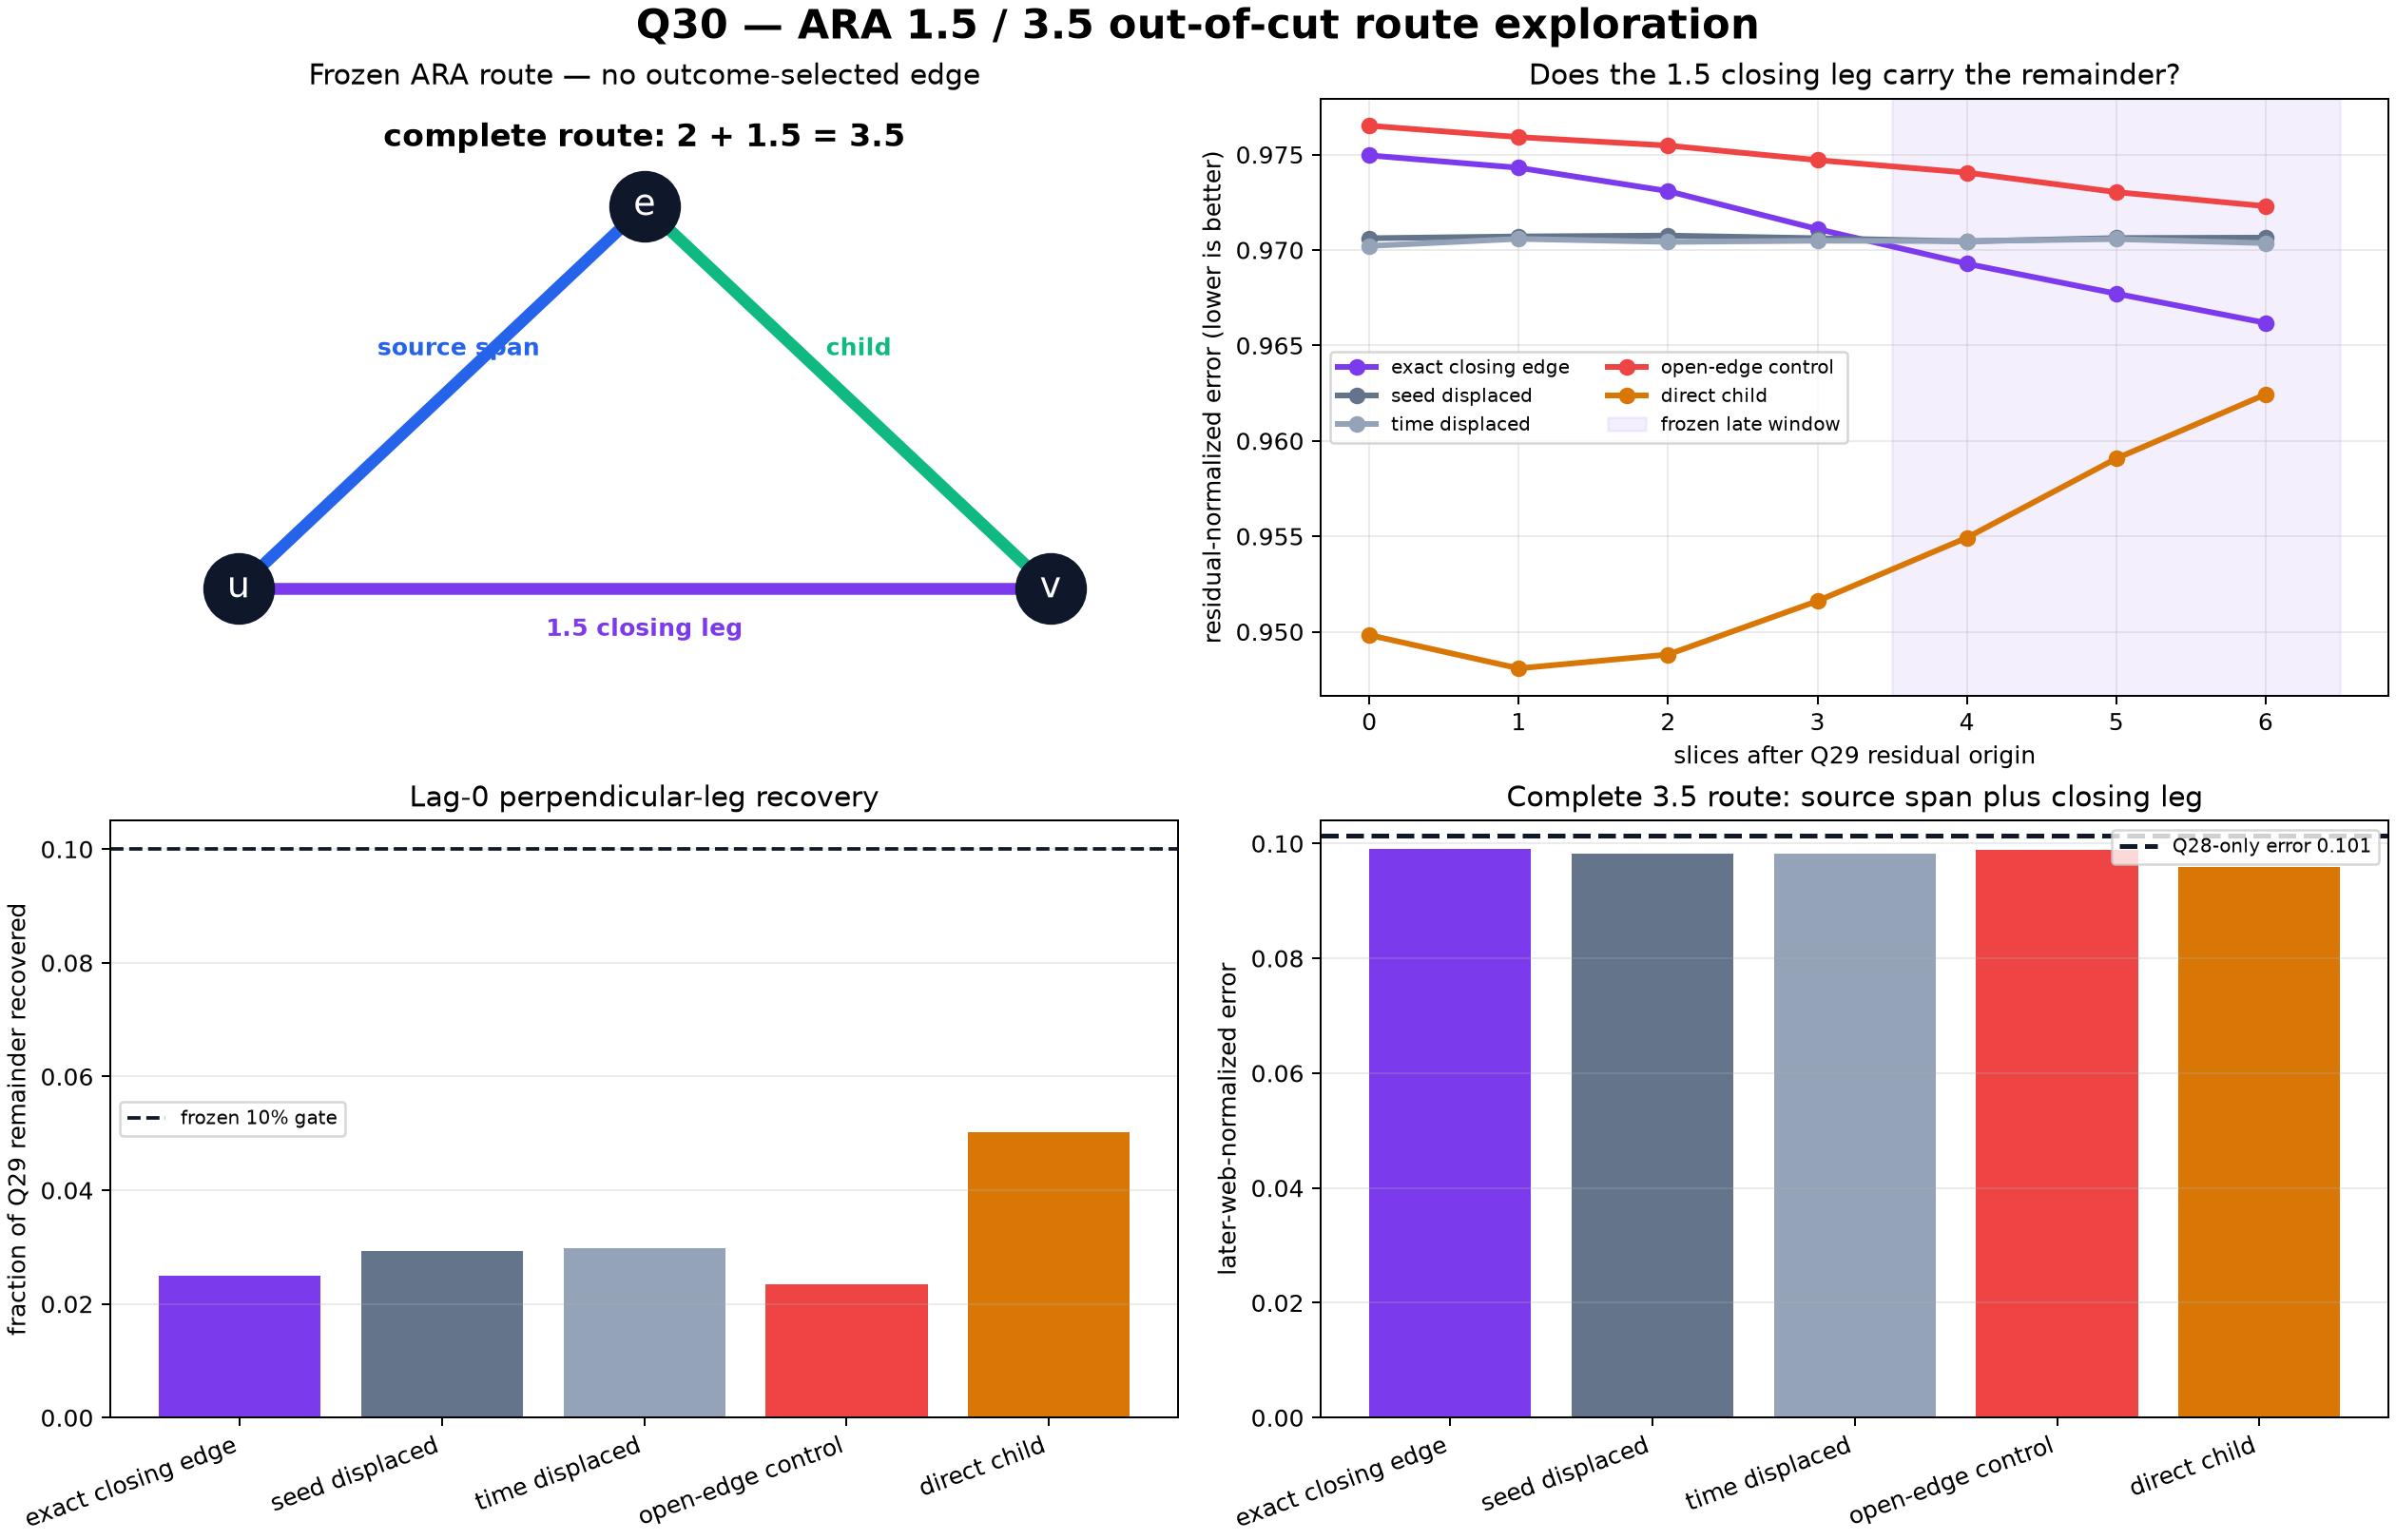

In [2]:
display(
    Image(
        filename=str(
            HERE / "Q30_ARA15_35_OUT_OF_CUT_ROUTE_GEOMETRY.png"
        )
    )
)

In [3]:
later = results["opened_later_half"]
lag0 = later["lag0"]
late = later["late_lags_4_to_6"]
print("Lag-0 exact 1.5 error:", lag0["exact_closure"]["residual_error"])
print("Lag-0 exact recovery:", lag0["exact_closure"]["residual_recovery"])
print("Lag-0 seed error:", lag0["seed"]["residual_error"])
print("Lag-0 time error:", lag0["time"]["residual_error"])
print("Late exact error:", late["exact_closure"]["residual_error"])
print("Late seed error:", late["seed"]["residual_error"])
print("Late time error:", late["time"]["residual_error"])
print("Frozen gates:", results["gates"])

Lag-0 exact 1.5 error: 0.9749573803278061
Lag-0 exact recovery: 0.025042619672193178
Lag-0 seed error: 0.9706164438411091
Lag-0 time error: 0.9702139259023912
Late exact error: 0.9677254963880328
Late seed error: 0.970575588259379
Late time error: 0.9704667859815111
Frozen gates: {'R1_perpendicular_1p5_route': False, 'R2_crossed_rung_3p5_composite': False, 'R3_continuation_beyond_q29_cut': False, 'R4_phase_b_identified': False}


## Interpretation

The exact closing edge is not the missing component at its proposed handover:
it recovers less than the displaced relations and less than the direct child.
The late exact edge is consistently but only minutely better than the
displaced controls. That weak delayed association is recorded as an
exploratory trace, not promoted to the 1.5/3.5 route.

The strongest remaining source limitation is exact diagonality. A source with
nonzero off-diagonal relations is still required to test a genuine
perpendicular continuation and stable Phase-B identity.

## Reproduction

```powershell
python q30_ara15_35_out_of_cut_route_exploration.py
python q30_validate_ara15_35_out_of_cut_route.py
python q30_build_notebook.py
```

Use the repository's Python 3.12 environment because the local Q27 scientific
cache contains CPython-3.12 binary packages.